In [19]:
# CELL 1: Install Library (Opsional - jika ada yang kurang)
!pip install pandas numpy matplotlib seaborn scikit-learn mlflow


[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# CELL 2: Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow
import mlflow.sklearn
import os

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [21]:
# CELL 3: Load Data (Dataset Baru: Wine)
import pandas as pd

# Baca file CSV (pastikan file wine.csv ada di folder yang sama)
df = pd.read_csv('wine.csv', header=None)

# Karena Wine dataset tidak punya header, kita beri nama kolom secara manual
# Kolom ke-0 adalah Target (Class), kolom 1-13 adalah Fitur
df.columns = ['class'] + [f'feature_{i}' for i in range(1, 14)]

# Pisahkan target ke kolom terpisah (agar mirip dengan struktur Iris)
df['target'] = df['class']
df = df.drop('class', axis=1)

print("✅ Data Wine berhasil dimuat!")
print(f"Jumlah data: {len(df)}")
print(df.head())

✅ Data Wine berhasil dimuat!
Jumlah data: 178
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      14.23       1.71       2.43       15.6        127       2.80   
1      13.20       1.78       2.14       11.2        100       2.65   
2      13.16       2.36       2.67       18.6        101       2.80   
3      14.37       1.95       2.50       16.8        113       3.85   
4      13.24       2.59       2.87       21.0        118       2.80   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0       3.06       0.28       2.29        5.64        1.04        3.92   
1       2.76       0.26       1.28        4.38        1.05        3.40   
2       3.24       0.30       2.81        5.68        1.03        3.17   
3       3.49       0.24       2.18        7.80        0.86        3.45   
4       2.69       0.39       1.82        4.32        1.04        2.93   

   feature_13  target  
0        1065       1  
1        1050       1  
2        1


📊 EDA - EKSPLORASI DATA

Statistik Deskriptif:
        feature_1   feature_2   feature_3   feature_4   feature_5   feature_6  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean    13.000618    2.336348    2.366517   19.494944   99.741573    2.295112   
std      0.811827    1.117146    0.274344    3.339564   14.282484    0.625851   
min     11.030000    0.740000    1.360000   10.600000   70.000000    0.980000   
25%     12.362500    1.602500    2.210000   17.200000   88.000000    1.742500   
50%     13.050000    1.865000    2.360000   19.500000   98.000000    2.355000   
75%     13.677500    3.082500    2.557500   21.500000  107.000000    2.800000   
max     14.830000    5.800000    3.230000   30.000000  162.000000    3.880000   

        feature_7   feature_8   feature_9  feature_10  feature_11  feature_12  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     2.029270    0.361854    1.590899    5.058090    0.9

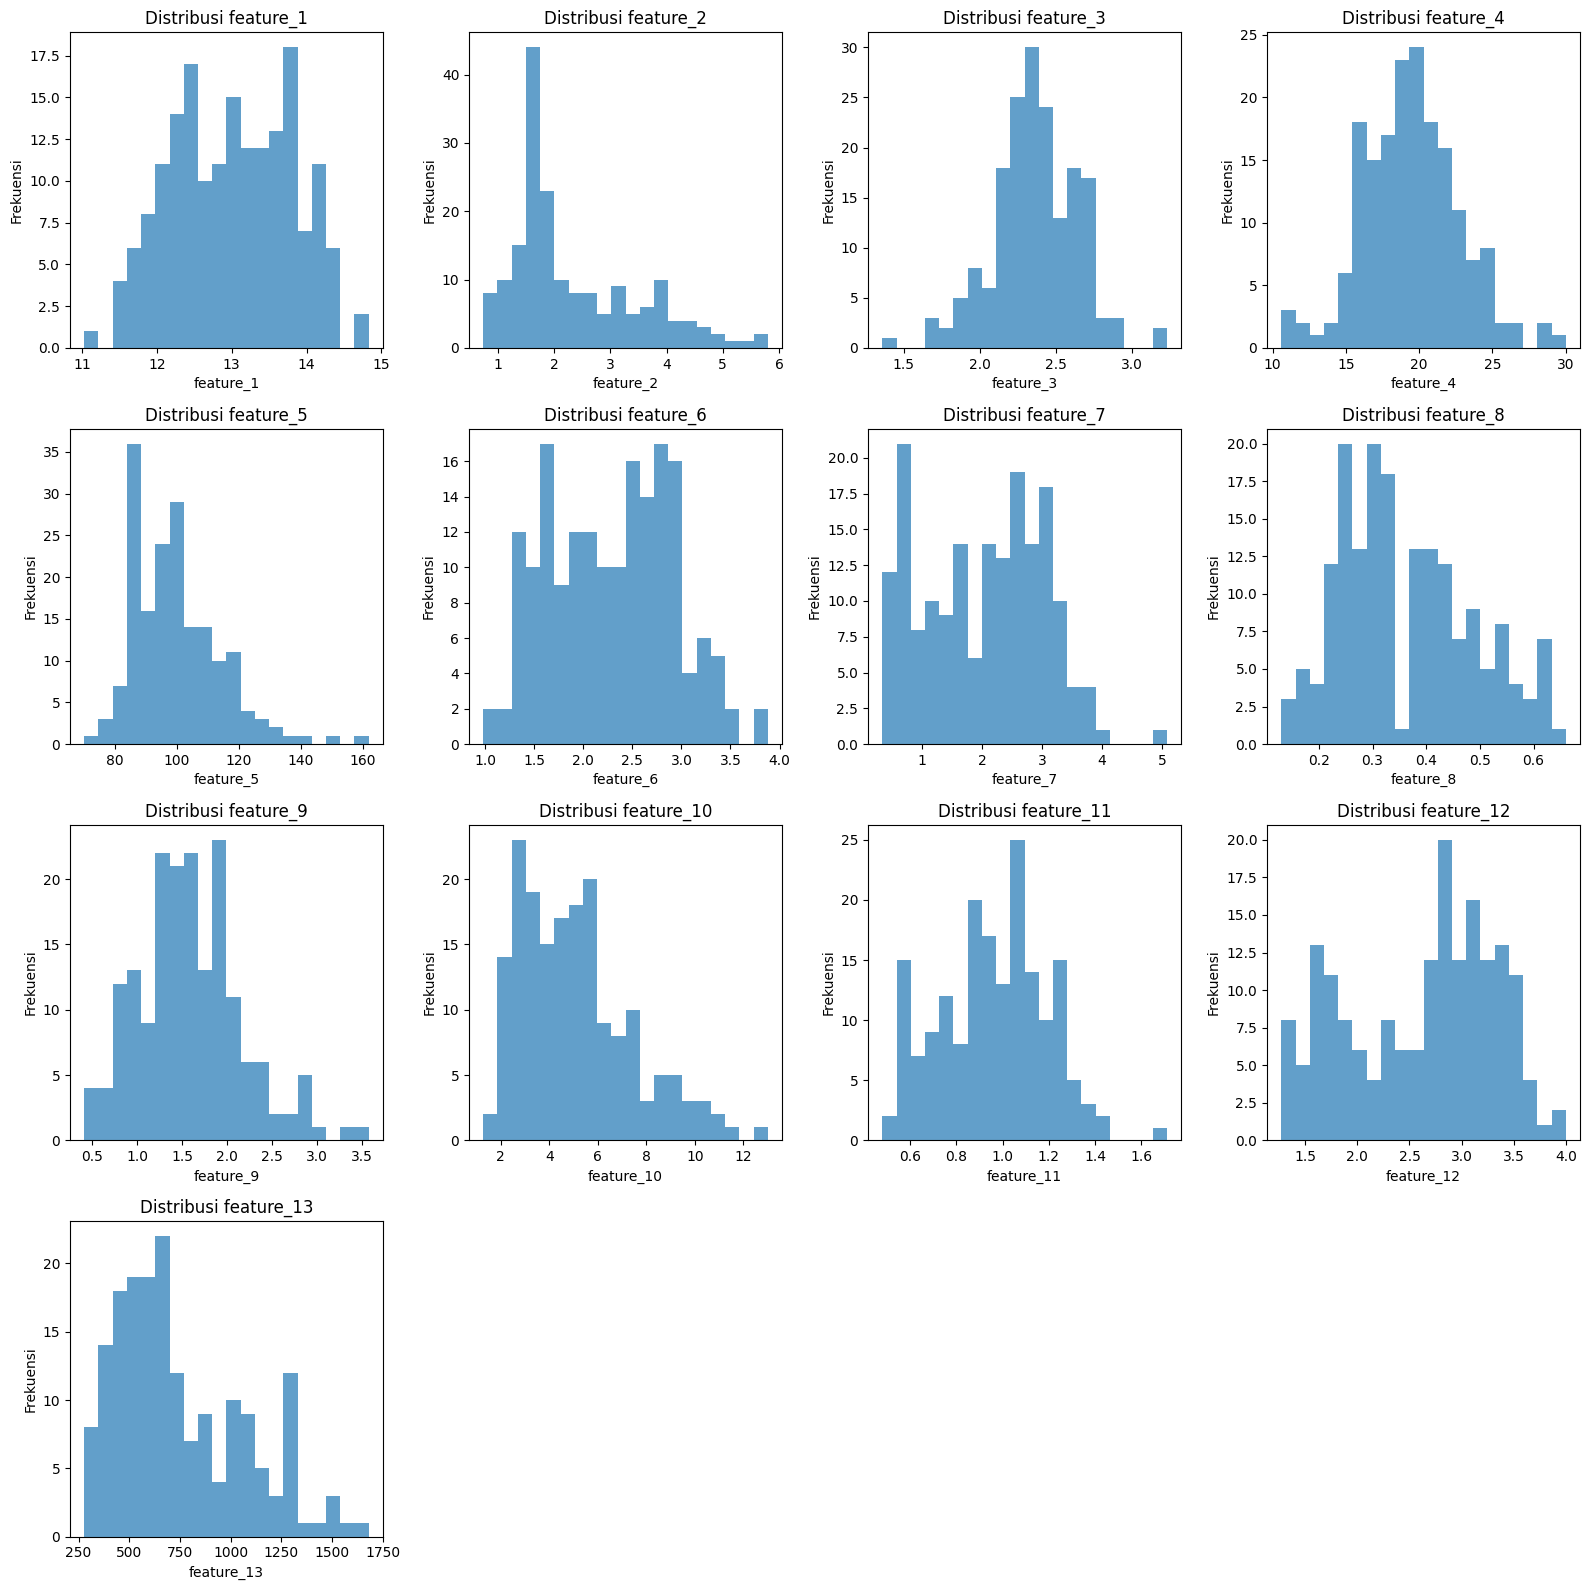

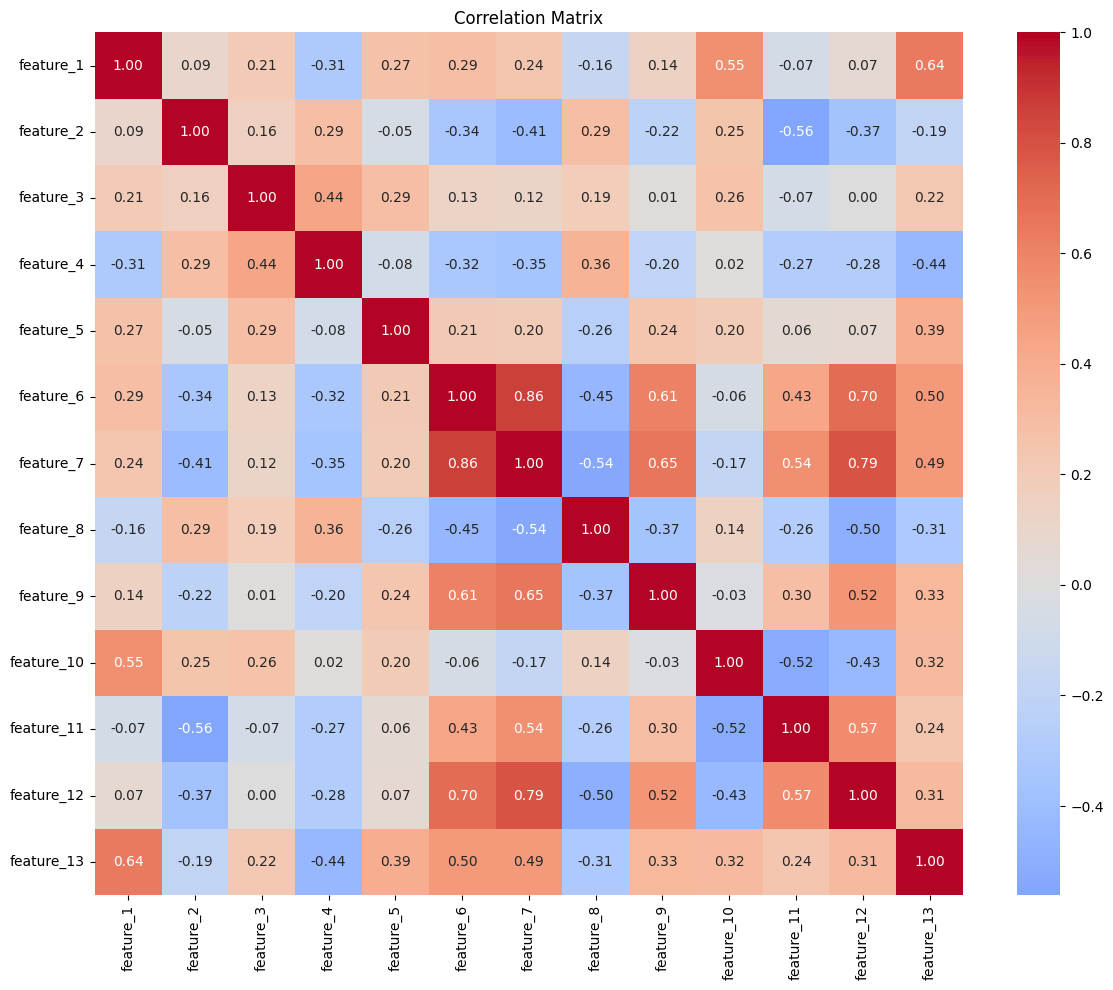

In [22]:
# CELL 4: EDA
print("\n" + "="*60)
print("📊 EDA - EKSPLORASI DATA")
print("="*60)

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nInformasi Dataset:")
print(df.info())

# --- PERBAIKAN BAGIAN DISTRIBUSI FITUR ---
# Karena ada 13 fitur, kita buat grid 4x4 (16 kotak) agar muat semua
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()  # Ubah matriks jadi array 1 dimensi agar mudah diloop

for i, col in enumerate(df.columns[:-1]):  # Loop semua fitur (kecuali target di kolom terakhir)
    ax = axes[i]
    ax.hist(df[col], bins=20, alpha=0.7)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

# Hapus grafik kosong yang tidak terpakai (karena 4x4 = 16, tapi fitur cuma 13)
for i in range(len(df.columns[:-1]), 16):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=300)
plt.show()

# --- CORRELATION MATRIX (Untuk 13 fitur) ---
plt.figure(figsize=(12, 10))
# df.iloc[:, :-1] artinya ambil semua kolom kecuali kolom terakhir (target)
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [23]:
# CELL 5: Preprocessing
print("\n" + "="*60)
print("🧹 PREPROCESSING")
print("="*60)

# === PERBAIKAN BAGIAN INI ===
# Jangan pakai data.feature_names. Langsung ambil semua kolom kecuali 'target'
X = df.drop(columns=['target'])
y = df['target']
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data berhasil diproses!")
print(f"Training: {len(X_train)} data")
print(f"Testing: {len(X_test)} data")

# Simpan hasil preprocessing ke CSV (tanpa menggunakan data.feature_names)
processed_df = pd.DataFrame(X_train_scaled, columns=X.columns)
processed_df['target'] = y_train.values
processed_df.to_csv('dataset_preprocessing.csv', index=False)

print("✅ Dataset preprocessing tersimpan!")


🧹 PREPROCESSING
✅ Data berhasil diproses!
Training: 142 data
Testing: 36 data
✅ Dataset preprocessing tersimpan!


In [24]:
# CELL 6: Training Model (Menggunakan data dari CSV yang sudah disimpan)
print("\n" + "="*60)
print("🤖 TRAINING MODEL")
print("="*60)

# Load data hasil preprocessing
train_df = pd.read_csv('dataset_preprocessing.csv')

X_train_final = train_df.drop(columns=['target']).values
y_train_final = train_df['target'].values

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_final, y_train_final)

y_pred = model.predict(X_train_final)
acc = accuracy_score(y_train_final, y_pred)

print(f"✅ Akurasi: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_train_final, y_pred))


🤖 TRAINING MODEL
✅ Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        57
           3       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



In [25]:
# CELL 7: Simpan ke MLflow
print("\n" + "="*60)
print("📝 SAVE TO MLFLOW")
print("="*60)

with mlflow.start_run(run_name="Eksperimen_Wine"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("test_size", 0.2)
    
    mlflow.log_metric("accuracy", acc)
    
    # PERBAIKAN DI SINI (Ganti "model" dengan name="model")
    mlflow.sklearn.log_model(model, name="model")
    
    mlflow.log_artifact("distribusi_data.png")
    mlflow.log_artifact("correlation_matrix.png")
    
    print("✅ Eksperimen berhasil disimpan ke MLflow!")


📝 SAVE TO MLFLOW
✅ Eksperimen berhasil disimpan ke MLflow!
